# Steam Games Market Analysis — Exploratory Data Analysis

**Goal:** Understand the landscape of Steam games and identify patterns that predict commercial success, with a focus on actionable insights for small/indie studios.

**Dataset:** `main_df2.csv` — 88,917 Steam games with pricing, genre, category, platform, developer, and estimated sales/revenue data.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('../data/main_df2.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (88917, 58)


,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,release_year,...,genre_racing,genre_rpg,genre_simulation,genre_sports,genre_strategy,genre_utilities,genre_video_production,genre_violent,estimated_sales,revenue
0,2358720,Black Myth: Wukong,0,14,True,True,True,59.99,1,2024,...,0,1,0,0,0,0,0,0,25659840,1.539334e+09
1,1091500,Cyberpunk 2077,0,19,True,True,True,59.99,1,2020,...,0,1,0,0,0,0,0,0,23601720,1.415867e+09
2,1245620,ELDEN RING,0,15,True,True,True,59.99,1,2022,...,0,1,0,0,0,0,0,0,23526240,1.411339e+09


## 1. Data Overview & Quality Check

In [22]:
print('=== Data Types & Missing Values ===')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
display(info_df)

print('\n=== Key Numeric Summary ===')
df[['price_usd', 'estimated_sales', 'revenue', 'dev_game_count', 'pub_game_count', 'supported_languages']].describe().round(2)

=== Data Types & Missing Values ===


,dtype,non_null,null_pct,n_unique
appid,int64,88917,0.00,88917
name,object,88917,0.00,88352
required_age,int64,88917,0.00,2
supported_languages,int64,88917,0.00,69
supports_windows,bool,88917,0.00,2
supports_mac,bool,88917,0.00,2
supports_linux,bool,88917,0.00,2
price_usd,float64,88917,0.00,404
achievement_systems,int64,88917,0.00,2
release_year,int64,88917,0.00,29



=== Key Numeric Summary ===


,price_usd,estimated_sales,revenue,dev_game_count,pub_game_count,supported_languages
count,88917.00,88917.0,8.891700e+04,88917.00,88917.00,88917.00
mean,9.49,25807.2,6.639340e+05,17.10,38.43,5.74
std,17.08,387199.3,1.381525e+07,79.53,126.41,14.22
min,0.50,100.0,9.000000e+01,0.00,0.00,1.00
25%,2.99,110.0,4.389000e+02,1.00,1.00,1.00
50%,5.99,130.0,9.990000e+02,3.00,3.00,1.00
75%,9.99,360.0,3.704700e+03,9.00,18.00,5.00
max,1900.00,34299420.0,1.539334e+09,3591.00,2375.00,103.00


## 2. Distribution of Sales & Revenue

Sales and revenue are extremely right-skewed — a handful of blockbusters dominate. We use log-scale to reveal the full distribution.

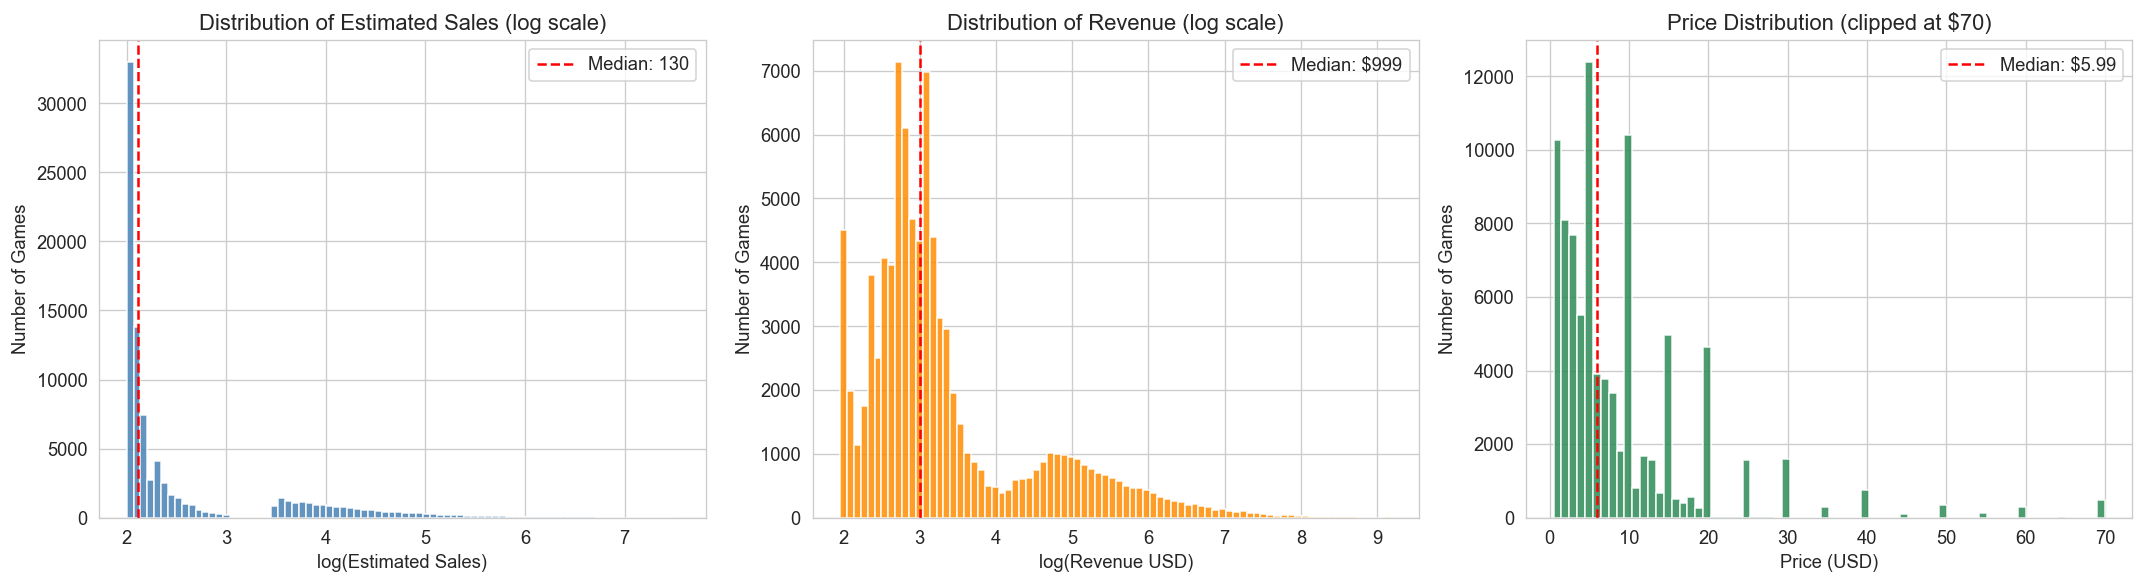

Games with zero sales: 0 (0.0%)
Free games: 0 (0.0%)
Top 1% of games account for 82.5% of total revenue


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sales distribution (log)
sales_pos = df.loc[df['estimated_sales'] > 0, 'estimated_sales']
axes[0].hist(np.log10(sales_pos), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log(Estimated Sales)')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Distribution of Estimated Sales (log scale)')
axes[0].axvline(np.log10(sales_pos.median()), color='red', ls='--', label=f'Median: {sales_pos.median():,.0f}')
axes[0].legend()

# Revenue distribution (log)
rev_pos = df.loc[df['revenue'] > 0, 'revenue']
axes[1].hist(np.log10(rev_pos), bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log(Revenue USD)')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Distribution of Revenue (log scale)')
axes[1].axvline(np.log10(rev_pos.median()), color='red', ls='--', label=f'Median: ${rev_pos.median():,.0f}')
axes[1].legend()

# Price distribution
axes[2].hist(df['price_usd'].clip(upper=70), bins=70, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Price (USD)')
axes[2].set_ylabel('Number of Games')
axes[2].set_title('Price Distribution (clipped at $70)')
axes[2].axvline(df['price_usd'].median(), color='red', ls='--', label=f'Median: ${df["price_usd"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Games with zero sales: {(df['estimated_sales'] == 0).sum()} ({(df['estimated_sales'] == 0).mean()*100:.1f}%)")
print(f"Free games: {(df['price_usd'] == 0).sum()} ({(df['price_usd'] == 0).mean()*100:.1f}%)")
print(f"Top 1% of games account for {df.nlargest(int(len(df)*0.01), 'revenue')['revenue'].sum() / df['revenue'].sum() * 100:.1f}% of total revenue")

### Key Insight: Winner-Take-All Market
The Steam market is extremely concentrated. A tiny fraction of games earn the vast majority of revenue. This is crucial context — any strategy must account for the fact that *most games sell very little*.

## 3. Temporal Trends: Market Growth & Saturation

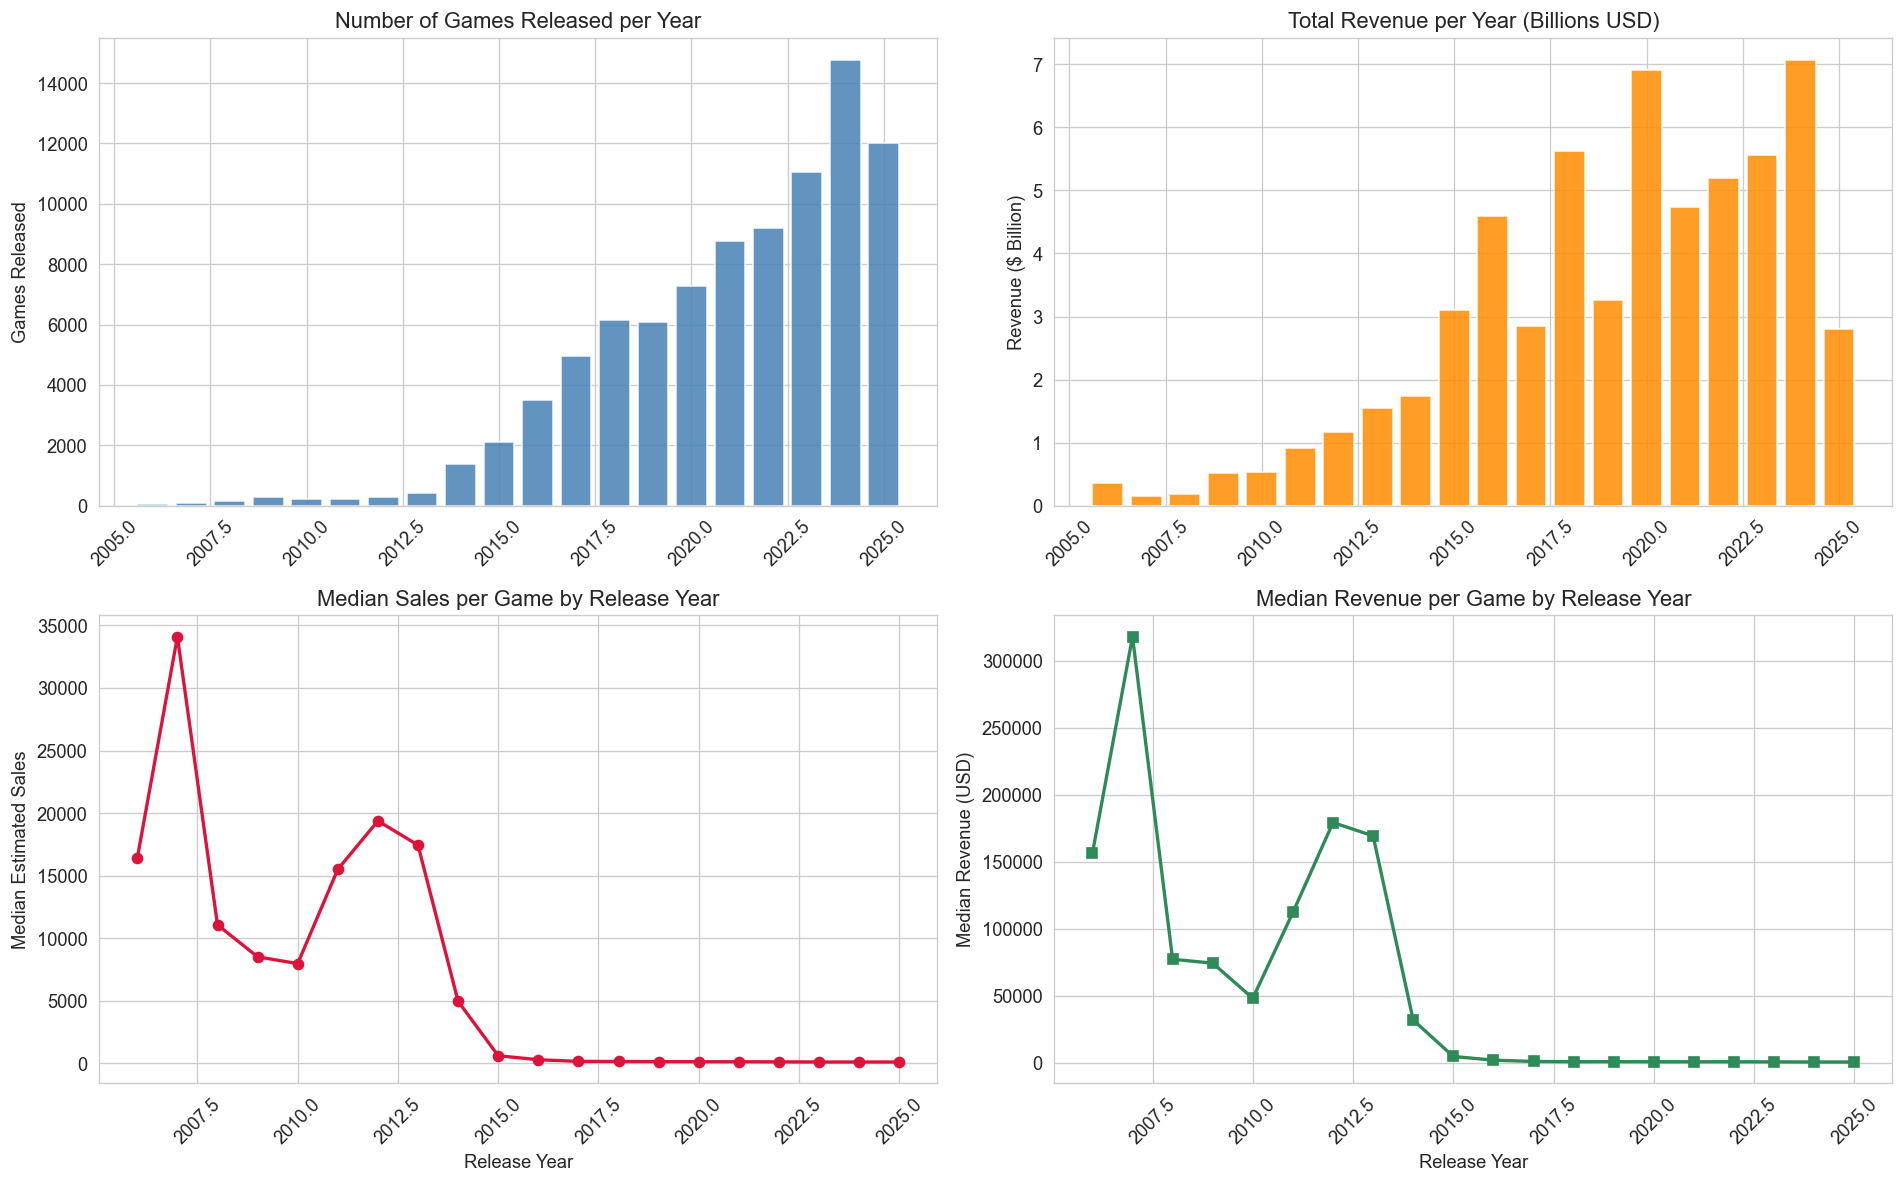

In [24]:
yearly = df.groupby('release_year').agg(
    n_games=('appid', 'count'),
    total_revenue=('revenue', 'sum'),
    median_sales=('estimated_sales', 'median'),
    mean_sales=('estimated_sales', 'mean'),
    p75_sales=('estimated_sales', lambda x: x.quantile(0.75)),
    median_revenue=('revenue', 'median')
).reset_index()
yearly = yearly[(yearly['release_year'] >= 2006) & (yearly['release_year'] <= 2025)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Number of games released per year
axes[0,0].bar(yearly['release_year'], yearly['n_games'], color='steelblue', alpha=0.85)
axes[0,0].set_title('Number of Games Released per Year')
axes[0,0].set_ylabel('Games Released')

# Total revenue per year
axes[0,1].bar(yearly['release_year'], yearly['total_revenue'] / 1e9, color='darkorange', alpha=0.85)
axes[0,1].set_title('Total Revenue per Year (Billions USD)')
axes[0,1].set_ylabel('Revenue ($ Billion)')

# Median sales per year
axes[1,0].plot(yearly['release_year'], yearly['median_sales'], 'o-', color='crimson', linewidth=2)
axes[1,0].set_title('Median Sales per Game by Release Year')
axes[1,0].set_ylabel('Median Estimated Sales')
axes[1,0].set_xlabel('Release Year')

# Revenue per game (median)
axes[1,1].plot(yearly['release_year'], yearly['median_revenue'], 's-', color='seagreen', linewidth=2)
axes[1,1].set_title('Median Revenue per Game by Release Year')
axes[1,1].set_ylabel('Median Revenue (USD)')
axes[1,1].set_xlabel('Release Year')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insight: Supply Explosion, Demand Dilution
Game releases have grown ~10x since 2014, but median sales per game have declined. The market is growing in aggregate, but **competition is fierce** — the typical game sells less than ever. Standing out requires deliberate strategy.

## 4. Genre Analysis: What Sells?

In [25]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
genre_names = [c.replace('genre_', '').replace('_', ' ').title() for c in genre_cols]

genre_stats = []
for col, name in zip(genre_cols, genre_names):
    subset = df[df[col] == 1]
    genre_stats.append({
        'Genre': name,
        'Count': len(subset),
        'Pct_of_Games': len(subset) / len(df) * 100,
        'Median_Sales': subset['estimated_sales'].median(),
        'Mean_Sales': subset['estimated_sales'].mean(),
        'P75_Sales': subset['estimated_sales'].quantile(0.75),
        'P90_Sales': subset['estimated_sales'].quantile(0.90),
        'Total_Revenue_B': subset['revenue'].sum() / 1e9,
        'Median_Price': subset['price_usd'].median()
    })

genre_df = pd.DataFrame(genre_stats).sort_values('Total_Revenue_B', ascending=False)
# Filter to main game genres (exclude tools/software)
game_genres = genre_df[genre_df['Count'] > 500].copy()
display(game_genres.round(1))

,Genre,Count,Pct_of_Games,Median_Sales,Mean_Sales,P75_Sales,P90_Sales,Total_Revenue_B,Median_Price
0,Action,36166,40.7,130.0,38516.9,360.0,15630.0,38.2,6.0
1,Adventure,35883,40.4,130.0,29310.0,500.0,15390.0,28.6,7.0
13,Rpg,16219,18.2,150.0,47367.9,4170.0,27150.0,23.2,8.0
10,Indie,63613,71.5,130.0,17437.4,320.0,10080.0,20.3,5.0
14,Simulation,19058,21.4,140.0,29890.9,3450.0,21567.0,12.6,7.0
16,Strategy,17603,19.8,130.0,24658.6,580.0,17970.0,11.8,7.0
4,Casual,39372,44.3,120.0,8055.3,230.0,5730.0,4.8,5.0
11,Massively Multiplayer,1072,1.2,150.0,134999.8,3540.0,48069.0,4.6,7.0
6,Early Access,8615,9.7,130.0,19985.9,250.0,8280.0,3.5,9.0
15,Sports,3922,4.4,140.0,12789.0,320.0,8580.0,1.5,8.0


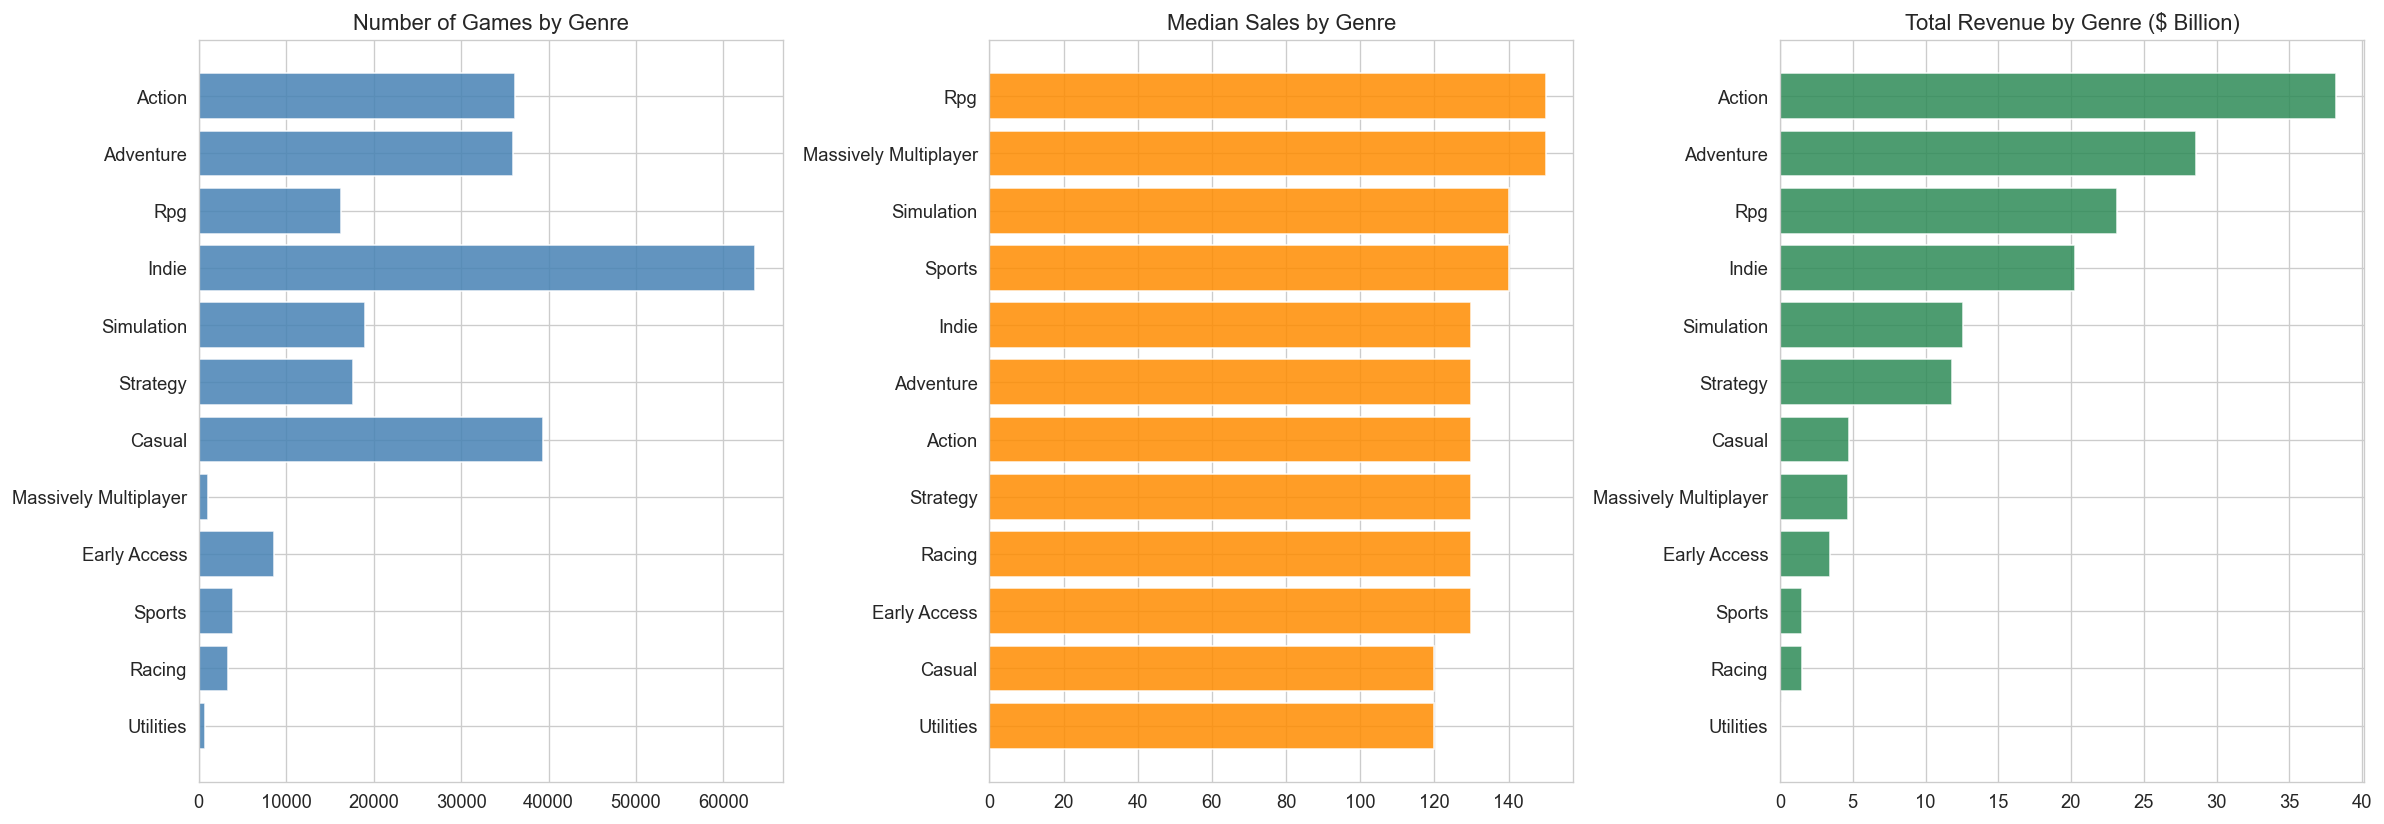

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

top_genres = game_genres.head(12)

# Count
axes[0].barh(top_genres['Genre'], top_genres['Count'], color='steelblue', alpha=0.85)
axes[0].set_title('Number of Games by Genre')
axes[0].invert_yaxis()

# Median sales
top_by_median = game_genres.nlargest(12, 'Median_Sales')
axes[1].barh(top_by_median['Genre'], top_by_median['Median_Sales'], color='darkorange', alpha=0.85)
axes[1].set_title('Median Sales by Genre')
axes[1].invert_yaxis()

# Total revenue
axes[2].barh(top_genres['Genre'], top_genres['Total_Revenue_B'], color='seagreen', alpha=0.85)
axes[2].set_title('Total Revenue by Genre ($ Billion)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Key Insight: Indie Dominance in Volume, Not Revenue
Indie games are the most common genre (~71%), but Action and RPG genres generate far higher median and total revenue. **For indie studios: genre choice matters.** Adding RPG or Simulation elements can significantly increase upside potential.

## 5. Price Strategy: The Quality Signal Effect

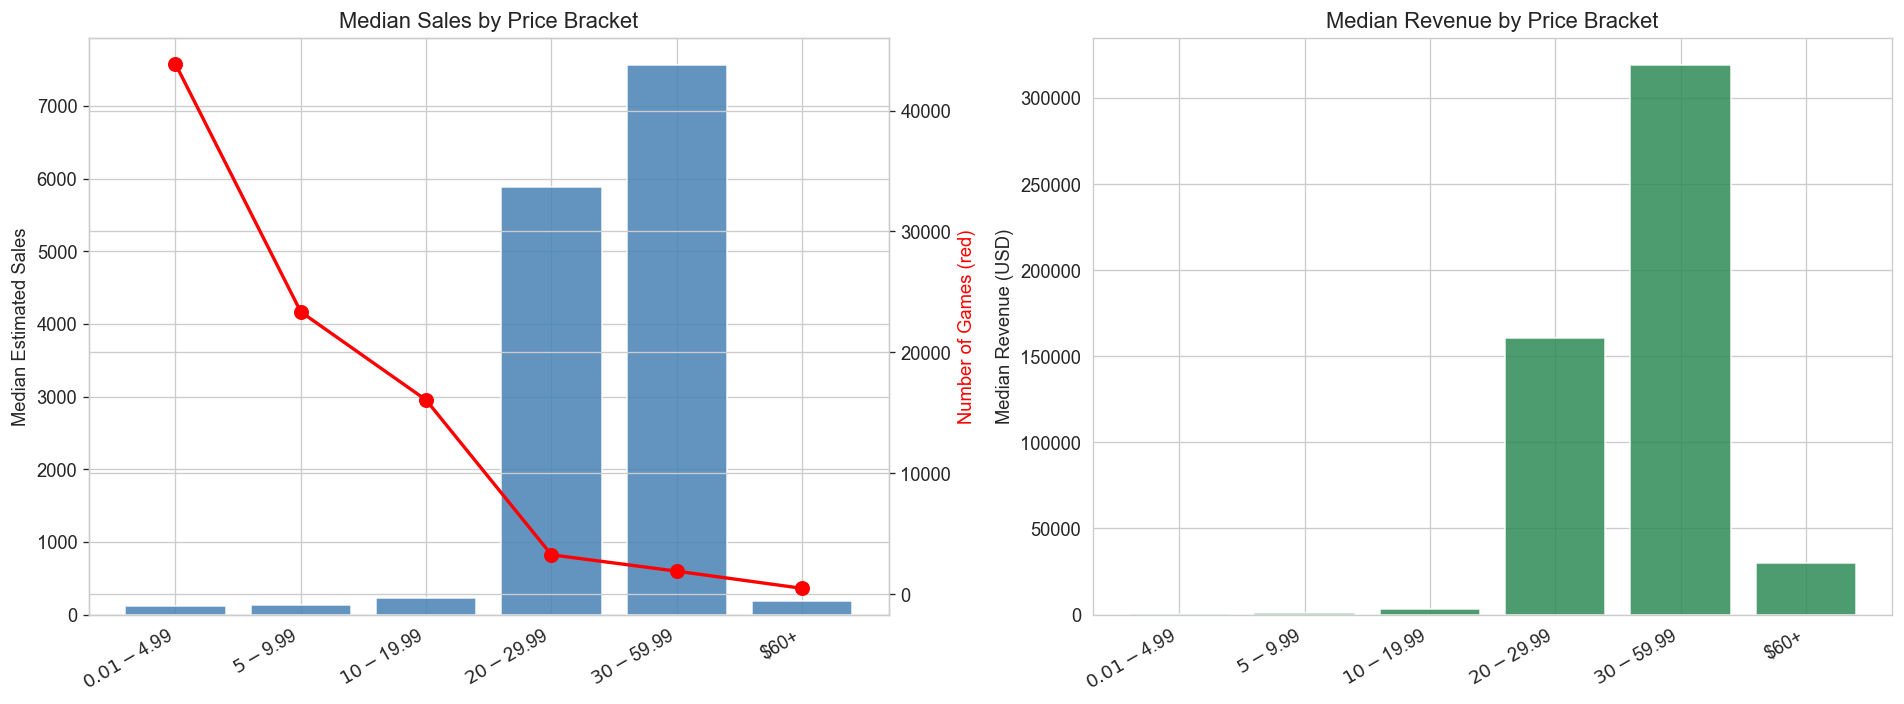

,price_bucket,n_games,median_sales,p25_sales,p75_sales,mean_sales,median_revenue
0,$0.01-$4.99,43853,120.0,110.0,190.0,3705.0,439.0
1,$5-$9.99,23350,130.0,110.0,330.0,16217.0,1144.0
2,$10-$19.99,16057,230.0,110.0,9210.0,47519.0,3398.0
3,$20-$29.99,3257,5880.0,130.0,43140.0,114978.0,160436.0
4,$30-$59.99,1903,7560.0,120.0,77520.0,309835.0,319120.0
5,$60+,485,190.0,110.0,240.0,54522.0,29998.0


In [27]:
# Create price buckets
bins = [0, 0.01, 4.99, 9.99, 19.99, 29.99, 59.99, 200]
labels = ['Free', '$0.01-$4.99', '$5-$9.99', '$10-$19.99', '$20-$29.99', '$30-$59.99', '$60+']
df['price_bucket'] = pd.cut(df['price_usd'], bins=bins, labels=labels, include_lowest=True)

price_stats = df.groupby('price_bucket', observed=True).agg(
    n_games=('appid', 'count'),
    median_sales=('estimated_sales', 'median'),
    p25_sales=('estimated_sales', lambda x: x.quantile(0.25)),
    p75_sales=('estimated_sales', lambda x: x.quantile(0.75)),
    mean_sales=('estimated_sales', 'mean'),
    median_revenue=('revenue', 'median')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(price_stats))
axes[0].bar(x, price_stats['median_sales'], color='steelblue', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_stats['price_bucket'], rotation=30, ha='right')
axes[0].set_title('Median Sales by Price Bracket')
axes[0].set_ylabel('Median Estimated Sales')

# Add game count on secondary axis
ax2 = axes[0].twinx()
ax2.plot(x, price_stats['n_games'], 'ro-', linewidth=2, markersize=8)
ax2.set_ylabel('Number of Games (red)', color='red')

axes[1].bar(x, price_stats['median_revenue'], color='seagreen', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(price_stats['price_bucket'], rotation=30, ha='right')
axes[1].set_title('Median Revenue by Price Bracket')
axes[1].set_ylabel('Median Revenue (USD)')

plt.tight_layout()
plt.show()

display(price_stats.round(0))

### Key Insight: Price as a Quality Signal
Higher-priced games have dramatically higher median sales. This is **not** because charging more causes sales — it's because price proxies for production quality and publisher confidence. Free and ultra-cheap games are mostly low-effort titles. **For indie studios:** pricing at $10-$20 signals quality and is associated with much better outcomes than the $1-$5 range.

## 6. Game Features (Categories) & Sales

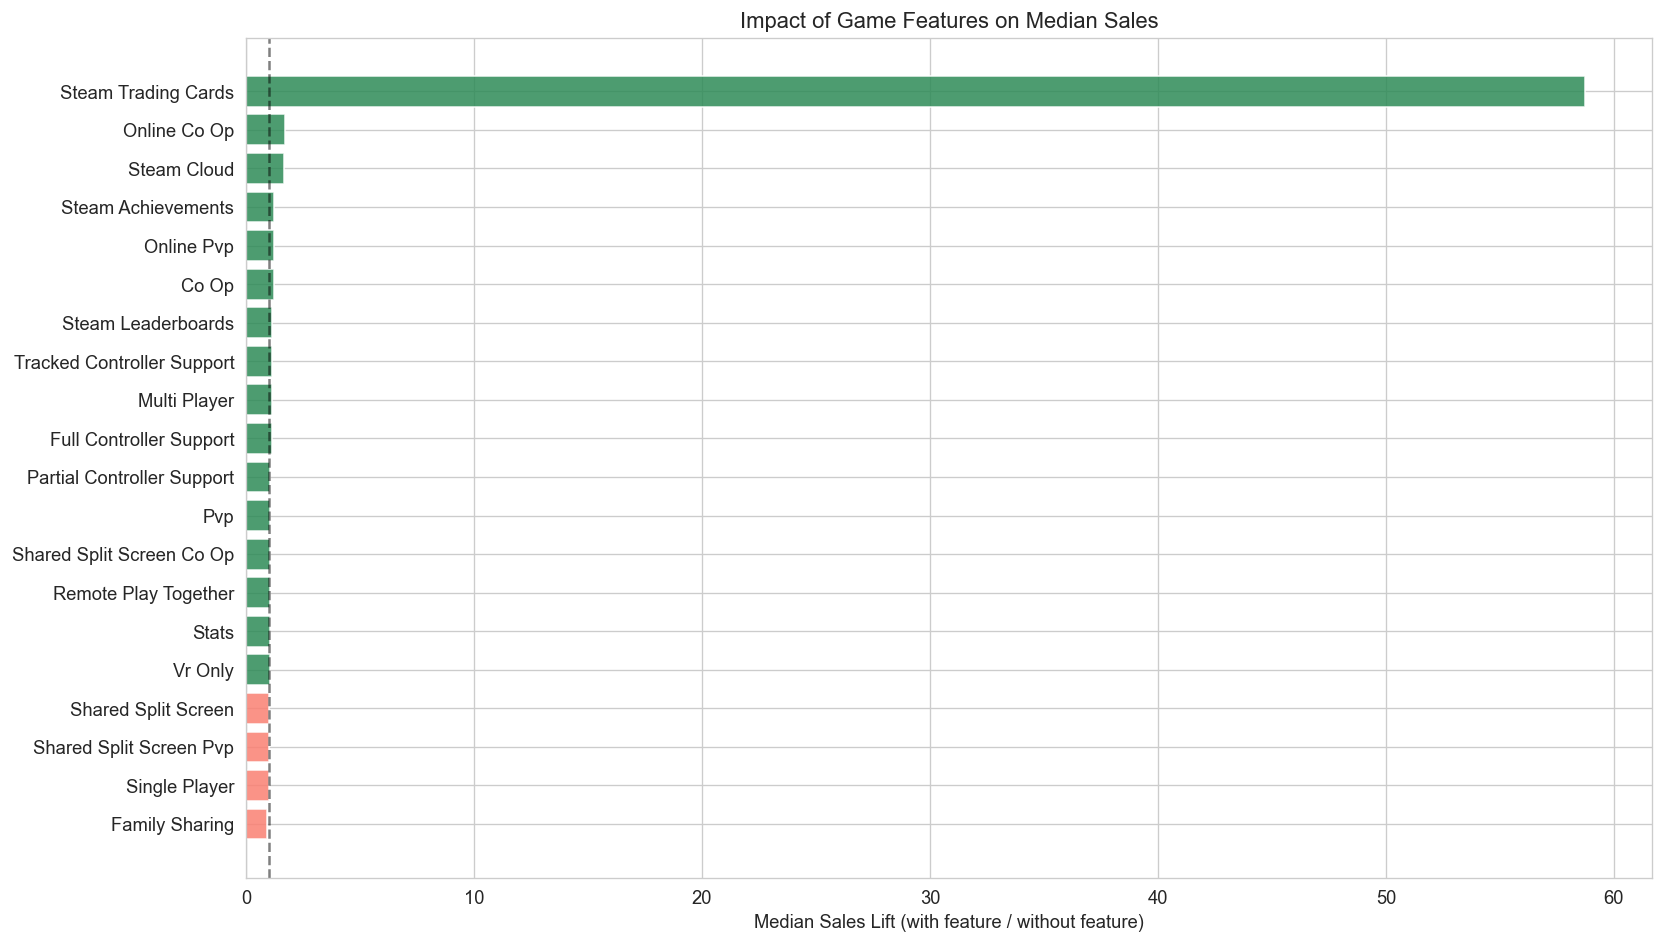


Top features by sales lift:


,Feature,Games_With,Median_Sales_With,Median_Sales_Without,Lift,P75_Sales_With
17,Steam Trading Cards,10073,7050.0,120.0,58.8,32250.0
4,Online Co Op,4460,220.0,130.0,1.7,16957.5
15,Steam Cloud,25011,200.0,120.0,1.7,9540.0
14,Steam Achievements,45313,150.0,120.0,1.2,4410.0
5,Online Pvp,5426,160.0,130.0,1.2,7770.0
0,Co Op,7921,160.0,130.0,1.2,8160.0
2,Full Controller Support,20471,150.0,130.0,1.2,5370.0
3,Multi Player,14214,150.0,130.0,1.2,5992.5
18,Tracked Controller Support,4378,150.0,130.0,1.2,300.0
16,Steam Leaderboards,7615,150.0,130.0,1.2,3405.0


In [28]:
cat_cols = [c for c in df.columns if c.startswith('cat_')]
cat_names = [c.replace('cat_', '').replace('_', ' ').title() for c in cat_cols]

cat_stats = []
for col, name in zip(cat_cols, cat_names):
    with_feat = df[df[col] == 1]['estimated_sales']
    without_feat = df[df[col] == 0]['estimated_sales']
    cat_stats.append({
        'Feature': name,
        'Games_With': len(with_feat),
        'Median_Sales_With': with_feat.median(),
        'Median_Sales_Without': without_feat.median(),
        'Lift': with_feat.median() / max(without_feat.median(), 1),
        'P75_Sales_With': with_feat.quantile(0.75)
    })

cat_df = pd.DataFrame(cat_stats).sort_values('Lift', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
cat_plot = cat_df[cat_df['Games_With'] > 200].sort_values('Lift')
colors = ['seagreen' if x > 1 else 'salmon' for x in cat_plot['Lift']]
ax.barh(cat_plot['Feature'], cat_plot['Lift'], color=colors, alpha=0.85)
ax.axvline(1, color='black', ls='--', alpha=0.5)
ax.set_xlabel('Median Sales Lift (with feature / without feature)')
ax.set_title('Impact of Game Features on Median Sales')
plt.tight_layout()
plt.show()

print('\nTop features by sales lift:')
display(cat_df[cat_df['Games_With'] > 200].head(10).round(1))

### Key Insight: Low-Cost Feature Wins
Features like **Steam Trading Cards**, **Steam Cloud Save**, **Achievements**, and **Full Controller Support** are associated with significantly higher sales. These are relatively low-cost to implement and serve as quality/polish signals to both the Steam algorithm and potential buyers.

## 7. Indie / Self-Published Analysis

In [29]:
# Define "indie" as self-published + tagged as indie genre
df['is_indie'] = ((df['genre_indie'] == 1) & (df['is_self_published'] == 1)).astype(int)
df['is_small_studio'] = (df['dev_game_count'] <= 5).astype(int)

segments = {
    'All Games': df,
    'Indie & Self-Published': df[df['is_indie'] == 1],
    'Small Studio (≤5 games)': df[df['is_small_studio'] == 1],
    'Small Indie Studio': df[(df['is_indie'] == 1) & (df['is_small_studio'] == 1)],
    'Established (>20 games)': df[df['dev_game_count'] > 20]
}

seg_stats = []
for name, subset in segments.items():
    seg_stats.append({
        'Segment': name,
        'N': len(subset),
        'Median_Sales': subset['estimated_sales'].median(),
        'Mean_Sales': subset['estimated_sales'].mean(),
        'P75_Sales': subset['estimated_sales'].quantile(0.75),
        'P90_Sales': subset['estimated_sales'].quantile(0.90),
        'Median_Price': subset['price_usd'].median(),
        'Median_Revenue': subset['revenue'].median(),
        'Pct_Free': (subset['price_usd'] == 0).mean() * 100
    })

seg_df = pd.DataFrame(seg_stats)
display(seg_df.round(1))

,Segment,N,Median_Sales,Mean_Sales,P75_Sales,P90_Sales,Median_Price,Median_Revenue,Pct_Free
0,All Games,88917,130.0,25807.2,360.0,12840.0,6.0,999.0,0.0
1,Indie & Self-Published,49578,130.0,15272.3,260.0,7110.0,5.0,798.4,0.0
2,Small Studio (≤5 games),59274,120.0,12874.8,240.0,6930.0,5.0,878.9,0.0
3,Small Indie Studio,35039,120.0,9745.0,210.0,4290.0,5.0,748.5,0.0
4,Established (>20 games),12186,150.0,64947.1,4140.0,37170.0,7.0,1225.9,0.0


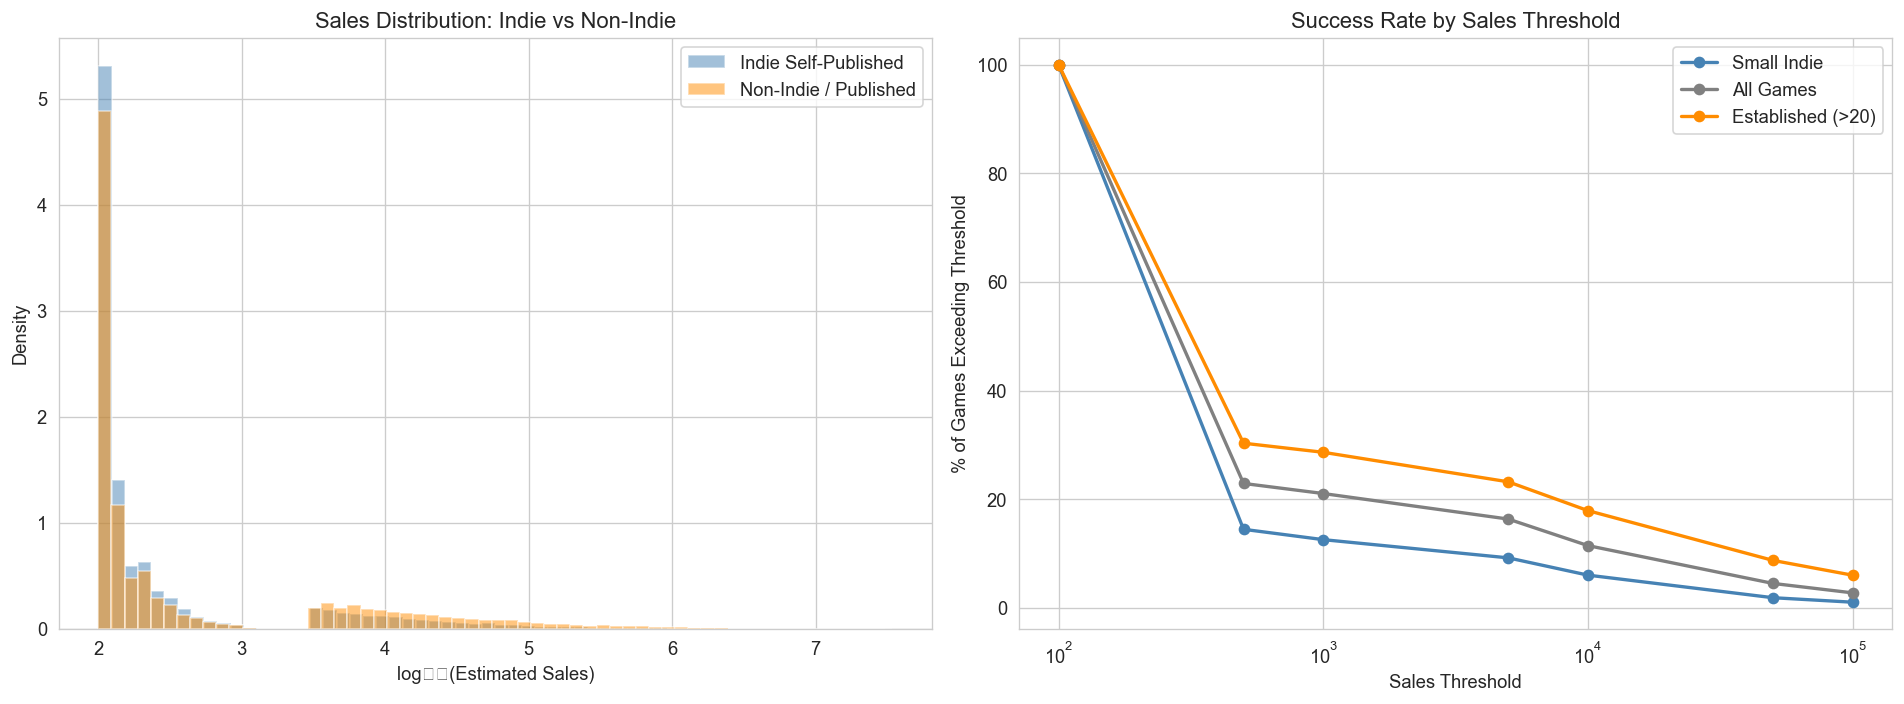

In [30]:
# Sales distribution comparison: Indie vs Non-Indie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color, mask in [('Indie Self-Published', 'steelblue', df['is_indie']==1), 
                            ('Non-Indie / Published', 'darkorange', df['is_indie']==0)]:
    sales = df.loc[mask & (df['estimated_sales'] > 0), 'estimated_sales']
    axes[0].hist(np.log10(sales), bins=60, alpha=0.5, label=label, color=color, density=True)

axes[0].set_xlabel('log₁₀(Estimated Sales)')
axes[0].set_ylabel('Density')
axes[0].set_title('Sales Distribution: Indie vs Non-Indie')
axes[0].legend()

# Success rate by segment (sales > different thresholds)
thresholds = [100, 500, 1000, 5000, 10000, 50000, 100000]
for name, subset, color in [('Small Indie', df[(df['is_indie']==1) & (df['is_small_studio']==1)], 'steelblue'),
                             ('All Games', df, 'gray'),
                             ('Established (>20)', df[df['dev_game_count']>20], 'darkorange')]:
    rates = [(subset['estimated_sales'] >= t).mean() * 100 for t in thresholds]
    axes[1].plot(thresholds, rates, 'o-', label=name, color=color, linewidth=2)

axes[1].set_xscale('log')
axes[1].set_xlabel('Sales Threshold')
axes[1].set_ylabel('% of Games Exceeding Threshold')
axes[1].set_title('Success Rate by Sales Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Insight: The Indie Challenge
Small indie studios face a steeper hill — lower median sales and lower success rates at every threshold. However, the gap **narrows at higher thresholds**, meaning indie breakout hits do exist and reach comparable scales. The key is maximizing the *controllable* factors (see modeling notebook).

## 8. Platform & Localization

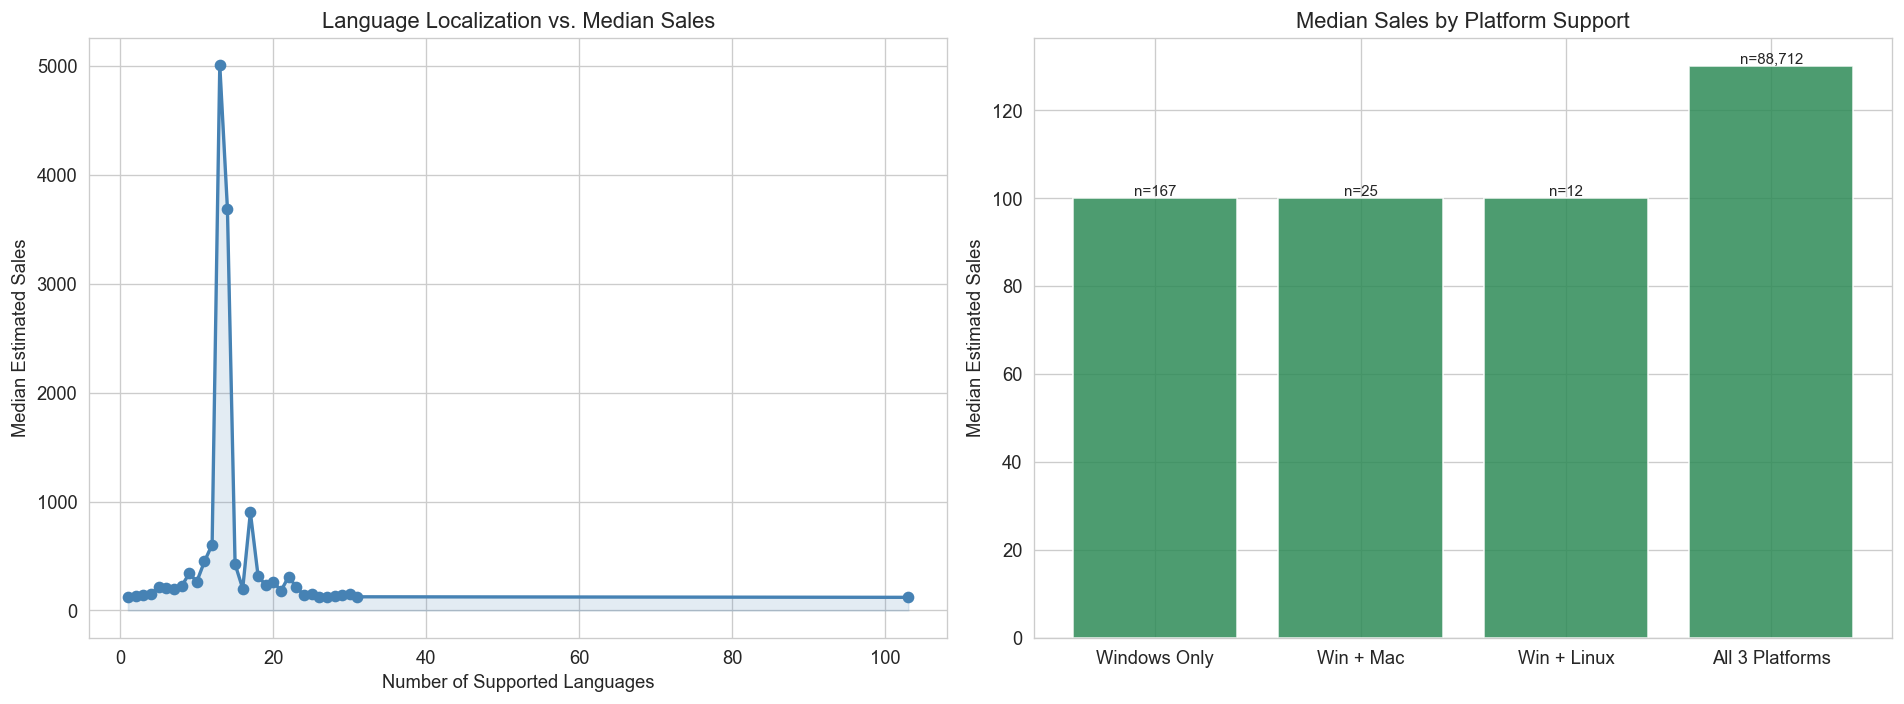

In [31]:
# Language count vs sales
lang_stats = df.groupby('supported_languages').agg(
    n_games=('appid', 'count'),
    median_sales=('estimated_sales', 'median'),
    p75_sales=('estimated_sales', lambda x: x.quantile(0.75))
).reset_index()
lang_stats = lang_stats[lang_stats['n_games'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lang_stats['supported_languages'], lang_stats['median_sales'], 'o-', color='steelblue', linewidth=2)
axes[0].fill_between(lang_stats['supported_languages'], 0, lang_stats['median_sales'], alpha=0.15, color='steelblue')
axes[0].set_xlabel('Number of Supported Languages')
axes[0].set_ylabel('Median Estimated Sales')
axes[0].set_title('Language Localization vs. Median Sales')

# Platform support
platform_combos = {
    'Windows Only': (df['supports_windows']==True) & (df['supports_mac']==False) & (df['supports_linux']==False),
    'Win + Mac': (df['supports_windows']==True) & (df['supports_mac']==True) & (df['supports_linux']==False),
    'Win + Linux': (df['supports_windows']==True) & (df['supports_mac']==False) & (df['supports_linux']==True),
    'All 3 Platforms': (df['supports_windows']==True) & (df['supports_mac']==True) & (df['supports_linux']==True),
}

plat_data = []
for name, mask in platform_combos.items():
    subset = df[mask]
    plat_data.append({'Platform': name, 'N': len(subset), 'Median_Sales': subset['estimated_sales'].median()})
plat_df = pd.DataFrame(plat_data)

axes[1].bar(plat_df['Platform'], plat_df['Median_Sales'], color='seagreen', alpha=0.85)
axes[1].set_title('Median Sales by Platform Support')
axes[1].set_ylabel('Median Estimated Sales')
# Add count annotations
for i, row in plat_df.iterrows():
    axes[1].annotate(f'n={row["N"]:,}', (i, row['Median_Sales']), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Key Insight: Localization Has Diminishing Returns
Moving from 1 to 3-5 languages provides the biggest sales lift. Beyond ~13 languages, gains plateau. **Priority languages** for small studios: English, Simplified Chinese, Russian, Spanish, German (the top 5 Steam markets).

## 9. Correlation Heatmap: Feature Relationships

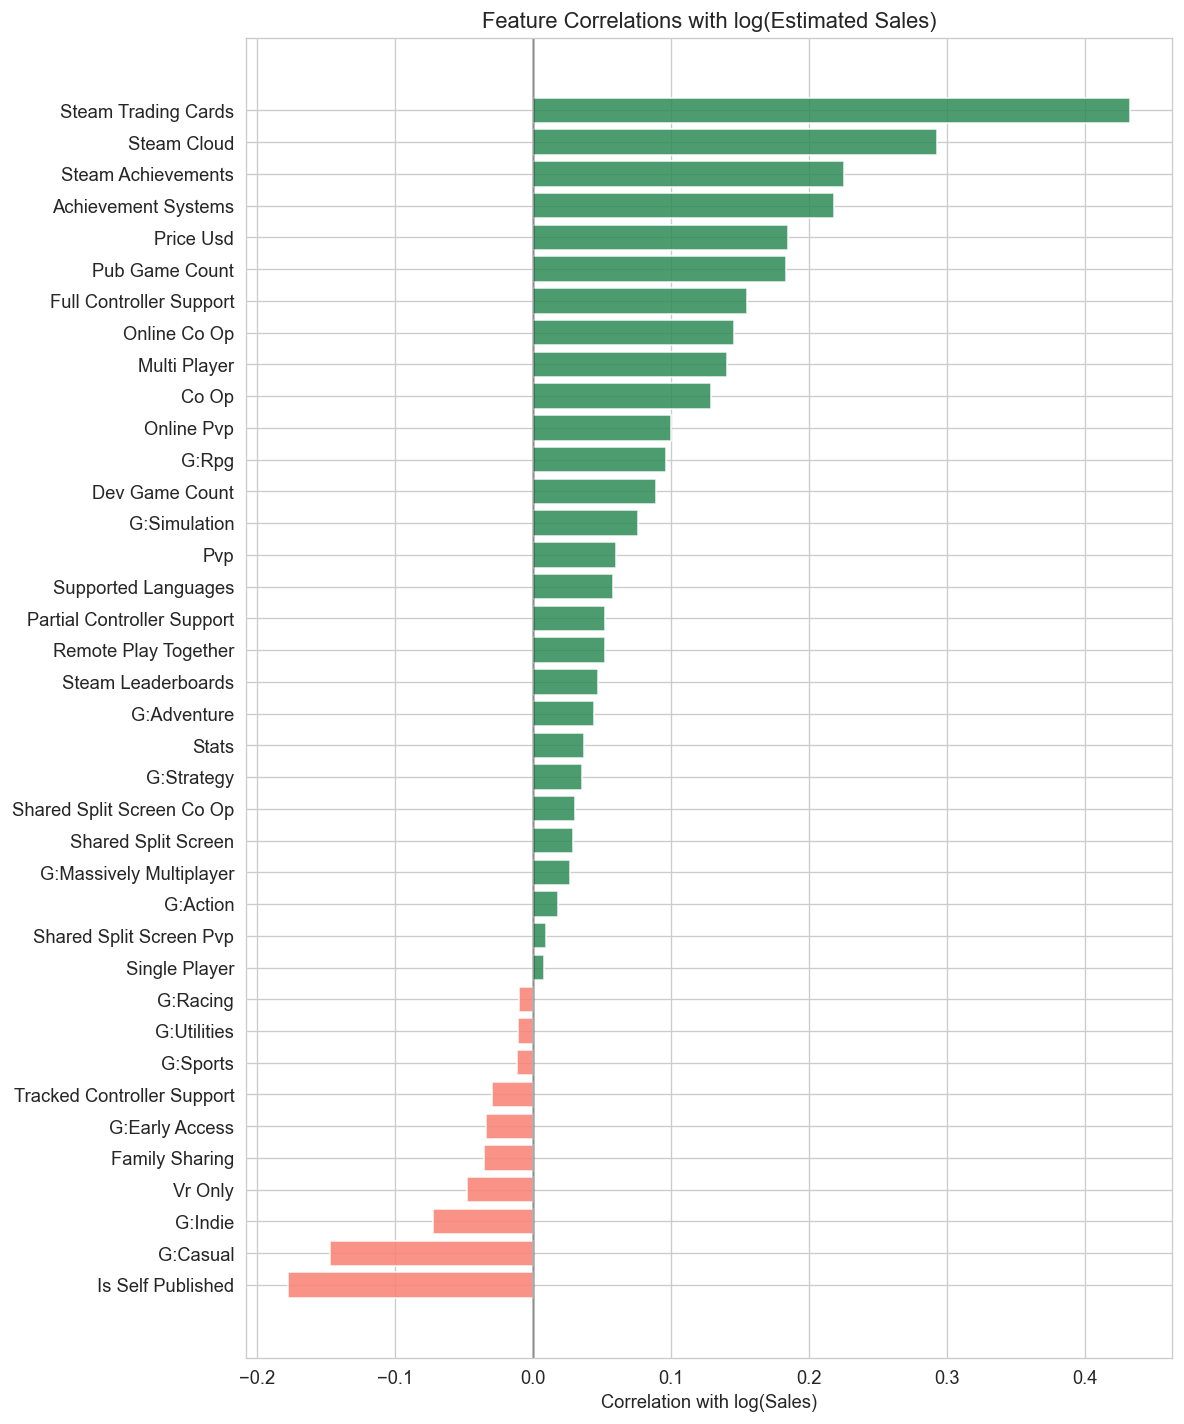

In [32]:
# Correlation of key features with log sales
df['log_sales'] = np.log1p(df['estimated_sales'])

feature_cols = ['price_usd', 'supported_languages', 'dev_game_count', 'pub_game_count', 
                'is_self_published', 'achievement_systems'] + \
               [c for c in cat_cols if df[c].sum() > 500] + \
               [c for c in genre_cols if df[c].sum() > 500]

corr_with_sales = df[feature_cols + ['log_sales']].corr()['log_sales'].drop('log_sales').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['seagreen' if x > 0 else 'salmon' for x in corr_with_sales]
ax.barh(range(len(corr_with_sales)), corr_with_sales.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(corr_with_sales)))
ax.set_yticklabels([c.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for c in corr_with_sales.index])
ax.set_xlabel('Correlation with log(Sales)')
ax.set_title('Feature Correlations with log(Estimated Sales)')
ax.axvline(0, color='black', ls='-', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Top Performing Games — What Do They Have in Common?

In [33]:
top100 = df.nlargest(100, 'estimated_sales')
print('=== Profile of Top 100 Best-Selling Games ===')
print(f"Median price: ${top100['price_usd'].median():.2f}  (All games: ${df['price_usd'].median():.2f})")
print(f"Median languages: {top100['supported_languages'].median():.0f}  (All games: {df['supported_languages'].median():.0f})")
print(f"Self-published: {top100['is_self_published'].mean()*100:.1f}%  (All games: {df['is_self_published'].mean()*100:.1f}%)")
print(f"Has achievements: {top100['achievement_systems'].mean()*100:.1f}%  (All: {df['achievement_systems'].mean()*100:.1f}%)")
print(f"Indie genre: {top100['genre_indie'].mean()*100:.1f}%  (All: {df['genre_indie'].mean()*100:.1f}%)")
print(f"\nTop genre breakdown:")
for col in genre_cols:
    pct = top100[col].mean() * 100
    if pct > 20:
        print(f"  {col.replace('genre_', '').title()}: {pct:.0f}%")

print(f"\nTop category breakdown:")
for col in cat_cols:
    pct = top100[col].mean() * 100
    if pct > 30:
        print(f"  {col.replace('cat_', '').replace('_', ' ').title()}: {pct:.0f}%")

=== Profile of Top 100 Best-Selling Games ===
Median price: $19.99  (All games: $5.99)
Median languages: 13  (All games: 1)
Self-published: 67.0%  (All games: 74.3%)
Has achievements: 88.0%  (All: 57.9%)
Indie genre: 40.0%  (All: 71.5%)

Top genre breakdown:
  Action: 69%
  Adventure: 44%
  Indie: 40%
  Rpg: 37%
  Simulation: 22%
  Strategy: 21%

Top category breakdown:
  Co Op: 49%
  Family Sharing: 85%
  Full Controller Support: 53%
  Multi Player: 66%
  Online Co Op: 42%
  Online Pvp: 32%
  Pvp: 32%
  Single Player: 87%
  Steam Achievements: 85%
  Steam Cloud: 67%
  Steam Trading Cards: 70%


In [34]:
# Show top 20 games
print('=== Top 20 Games by Estimated Sales ===')
display(top100[['name', 'price_usd', 'estimated_sales', 'revenue', 'genre_indie', 
                 'is_self_published', 'supported_languages', 'release_year']].head(20))

=== Top 20 Games by Estimated Sales ===


,name,price_usd,estimated_sales,revenue,genre_indie,is_self_published,supported_languages,release_year
18,Terraria,9.99,34299420,3.426512e+08,1,1,9,2011
3,Rust,39.99,31301130,1.251732e+09,1,1,25,2018
23,Garry's Mod,9.99,30406830,3.037642e+08,1,0,31,2006
0,Black Myth: Wukong,59.99,25659840,1.539334e+09,0,1,14,2024
1,Cyberpunk 2077,59.99,23601720,1.415867e+09,0,1,19,2020
5,The Witcher 3: Wild Hunt,39.99,23542050,9.414466e+08,0,1,17,2015
2,ELDEN RING,59.99,23526240,1.411339e+09,0,1,15,2022
6,HELLDIVERS™ 2,39.99,22796100,9.116160e+08,0,0,14,2024
38,Left 4 Dead 2,9.99,22590690,2.256810e+08,0,1,28,2009
13,Euro Truck Simulator 2,19.99,21158010,4.229486e+08,1,1,30,2012


### Key Insight: The Anatomy of a Hit
Top-selling games are disproportionately: Action or RPG genre, priced at $20+, support many languages, have achievements and cloud save enabled, and include some multiplayer component. Notably, many top games are **still indie or self-published** — proving that small studios *can* compete at the highest level.

## Summary of EDA Findings

| Finding | Implication |
|---------|------------|
| Market is extremely concentrated (top 1% earns most revenue) | Success requires differentiation, not just participation |
| Game releases grew 10x since 2014; median sales declined | Increased competition demands deliberate strategy |
| Higher price → higher median sales (quality signal) | Don't underprice — $10-$20 is the sweet spot for indie |
| Trading Cards, Cloud Save, Achievements boost sales | Low-cost, high-impact polish signals |
| 3-5 languages give the biggest localization lift | Prioritize EN, ZH, RU, ES, DE |
| Action/RPG genres have highest revenue potential | Genre choice matters — consider genre blending |
| Indie studios can and do produce breakout hits | Controllable factors can close the gap |

**Next:** See `steam_modeling.ipynb` for predictive models that quantify these effects and provide prioritized recommendations.